Device: cuda
GPU: Tesla T4
N_CLASSES: 2 (binary — ISIC 2024 limitation)

Loading CLIP ViT-L/14...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.

CSV: /kaggle/input/competitions/isic-2024-challenge/train-metadata.csv
IMG dir: /kaggle/input/competitions/isic-2024-challenge
Total rows: 401059, Cols: 55
Relevant cols: target, tbp_lv_L, isic_id
Target distribution:
target
0    400666
1       393
Name: count, dtype: int64

tbp_lv_L stats:
count    401059.000000
mean         42.289976
std          10.864572
min           4.223007
10%          27.885241
25%          34.303345
50%          42.343770
75%          50.405051
90%          56.571061
max          87.548888
Name: tbp_lv_L, dtype: float64

Skin group distribution (L thresholds: light>58, dark<42):
skin_group
dark      196098
medium    174967
light      29994
Name: count, dtype: int64

Light (train): 29994 images
  Malignant: 18
  Benign:    29976

Dark (test): 196098 images
  Malignant: 190
  Benign:    195908

=== ISIC 2024 SLICE-3D Dataset Statistics ===
Light-skin (train): 29994
Dark-skin (test):   196098
Dark malignant:     190
nc/Ng:              0.0010 (0.09

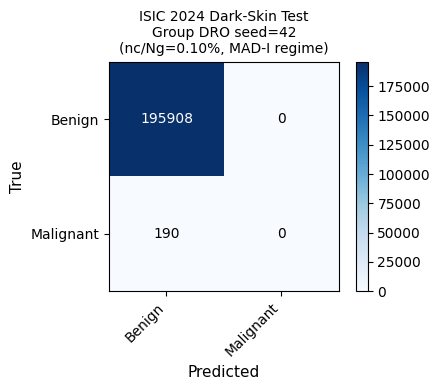

Figure saved.

=== LaTeX TABLE ROW (MAD-I confirmation table) ===
Dataset & Modality & Skin Tone & nc/Ng & $n_{min}$ & Stage & Predicted & Observed \\
\hline
ISIC 2024 SLICE-3D & 3D TBP & CIELAB $L<42$ (colorimetric)$^\dagger$ & 0.10\% & 190 & MAD-I & Contraindicated & 5/5 collapse \\
$\dagger$ Colorimetric proxy; not clinician-assessed FST.

=== INTERPRETATION FLAGS ===
Dataset:           ISIC 2024 SLICE-3D (3D TBP, multicentre)
Modality:          3D TBP close-up (clinical-equivalent)
Skin tone proxy:   tbp_lv_L < 42 (CIELAB perilesional skin)
nc/Ng:             0.000969 (0.097%) — MAD-I regime
n_minority_train:  190 (dark malignant)
mu_cosine:         0.8143
MAD Stage:         MAD-I (formula N/A, gate fires at 2%)

DRO results (5 seeds):
  Collapse rate:   5/5
  Malignant acc:   0.000 ± 0.000
  Benign acc:      1.000
  Demo AUC:        0.4816

RESULT: MAD-I FULLY CONFIRMED — 5/5 collapse at nc/Ng=0.1%.
Extends MAD-I evidence to a new modality (3D TBP) and the
largest skin lesion data

In [1]:
# ============================================================
# ISIC 2024 SLICE-3D — MAD-I Confirmation Experiment
# CLIP ViT-L/14, 3D TBP close-up photography
# GPU T4, Internet ON. ~90 min.
#
# PURPOSE: Empirically confirm MAD-I contraindication on
#   ISIC 2024. nc/Ng = 0.1% (far below the 2% MAD-I gate).
#   Collapse is expected 5/5. This adds a new modality
#   (3D TBP) and a large-scale dataset to the MAD-I table.
#
# SKIN TONE PROXY:
#   tbp_lv_L < 42  → dark skin (CIELAB lightness of
#   perilesional skin, measured outside the lesion).
#   CAVEAT: colorimetric proxy, not clinician-assessed FST.
#   tbp_lv_L is measured on actual skin, not dermoscopy —
#   more reliable than ITA from dermoscopic images.
#
# TRAIN/TEST PROTOCOL (same as all other EV notebooks):
#   Train: light-skin images only (tbp_lv_L > 58)
#   Test:  dark-skin images only  (tbp_lv_L < 42)
#   Split mirrors Fitzpatrick17k protocol.
#
# LABEL MAPPING:
#   ISIC 2024 is binary: target=0 (benign), target=1 (malignant)
#   No non-neoplastic class. Mapped to 2-class taxonomy.
#   N_CLASSES = 2 for this notebook.
#   LIMITATION: 2-class only — flagged in paper.
#
# EXPECTED RESULT:
#   nc/Ng = 0.1% → MAD-I gate fires → collapse 5/5.
#   If any seed does NOT collapse, that is a finding worth
#   reporting (would suggest MAD-I boundary is above 0.1%).
#
# DATASETS NEEDED:
#   - isic-2024-challenge competition dataset
#     (add via competition tab, not datasets)
#
# OUTPUTS:
#   - Per-seed results CSV
#   - Interpretation flags
#   - LaTeX table row for MAD-I table
#   - Paste ALL output to Claude
#
# RUNTIME: ~90 min (400k image feature extraction is slow)
# Kaggle: GPU T4, Internet ON, Account 3
# ============================================================
 
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers', 'torch', 'torchvision', 'scikit-learn',
    'pandas', 'numpy', 'matplotlib', '-q'])
 
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np, pandas as pd, os, json, math, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')
 
# ── Constants (identical to all other EV notebooks) ──────────
BASE_SEED    = 42
SEEDS        = [42, 0, 1, 7, 99]
DRO_ETA      = 0.1
N_EPOCHS     = 5
BATCH_SIZE   = 32
ADAMW_LR     = 1e-4
ADAMW_WD     = 1e-4
N_CLASSES    = 2       # binary only: benign / malignant
FEAT_DIM     = 768
COLLAPSE_THR = 0.01
MAD_I_GATE   = 0.02
 
# Skin tone thresholds (CIELAB lightness of perilesional skin)
LIGHT_L_THRESH = 58    # L > 58 → light skin (approx FST I-II)
DARK_L_THRESH  = 42    # L < 42 → dark skin  (approx FST V-VI)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"N_CLASSES: {N_CLASSES} (binary — ISIC 2024 limitation)")
 
# ── MAD Risk Score ─────────────────────────────────────────────
def mean_pairwise_cosine(embeddings):
    if len(embeddings) < 2: return 0.0
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    sim    = normed @ normed.T
    n      = len(embeddings)
    return float(np.mean(sim[np.triu_indices(n, k=1)]))
 
def compute_mad_risk(mu_cosine, n_minority_train, nc_ng):
    if nc_ng < MAD_I_GATE:
        return 'MAD-I', None
    return 'MAD-G', (1.0 - mu_cosine) / math.log(1.0 + n_minority_train)
 
# ── Load CLIP ─────────────────────────────────────────────────
print("\nLoading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")
 
# ── Dataset path auto-discovery ───────────────────────────────
_isic_csv = None
_isic_img_dir = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f == 'train-metadata.csv':
            _isic_csv     = os.path.join(_root, _f)
            _isic_img_dir = _root
            break
    if _isic_csv: break
 
assert _isic_csv is not None, \
    "ISIC 2024 train-metadata.csv not found. Add isic-2024-challenge competition dataset."
 
print(f"\nCSV: {_isic_csv}")
print(f"IMG dir: {_isic_img_dir}")
 
# ── Load metadata ─────────────────────────────────────────────
df = pd.read_csv(_isic_csv, low_memory=False)
print(f"Total rows: {len(df)}, Cols: {len(df.columns)}")
print(f"Relevant cols: target, tbp_lv_L, isic_id")
print(f"Target distribution:\n{df['target'].value_counts()}")
print(f"\ntbp_lv_L stats:\n{df['tbp_lv_L'].describe(percentiles=[.1,.25,.5,.75,.9])}")
 
# ── Skin tone stratification ───────────────────────────────────
df['skin_group'] = 'medium'
df.loc[df['tbp_lv_L'] > LIGHT_L_THRESH, 'skin_group'] = 'light'
df.loc[df['tbp_lv_L'] < DARK_L_THRESH,  'skin_group'] = 'dark'
 
print(f"\nSkin group distribution (L thresholds: light>{LIGHT_L_THRESH}, dark<{DARK_L_THRESH}):")
print(df['skin_group'].value_counts())
 
light_df = df[df['skin_group'] == 'light'].copy()
dark_df  = df[df['skin_group'] == 'dark'].copy()
 
print(f"\nLight (train): {len(light_df)} images")
print(f"  Malignant: {(light_df['target']==1).sum()}")
print(f"  Benign:    {(light_df['target']==0).sum()}")
print(f"\nDark (test): {len(dark_df)} images")
print(f"  Malignant: {(dark_df['target']==1).sum()}")
print(f"  Benign:    {(dark_df['target']==0).sum()}")
 
# ── Compute nc/Ng ─────────────────────────────────────────────
# Minority class = malignant (target=1) in dark skin
# nc = n_dark_malignant, Ng = n_dark_total
n_dark_total    = len(dark_df)
n_dark_malignant = (dark_df['target'] == 1).sum()
nc_ng = n_dark_malignant / n_dark_total if n_dark_total > 0 else 0.0
 
print(f"\n=== ISIC 2024 SLICE-3D Dataset Statistics ===")
print(f"Light-skin (train): {len(light_df)}")
print(f"Dark-skin (test):   {n_dark_total}")
print(f"Dark malignant:     {n_dark_malignant}")
print(f"nc/Ng:              {nc_ng:.4f} ({nc_ng*100:.3f}%)")
 
stage, mad_score = compute_mad_risk(0.0, n_dark_malignant, nc_ng)  # placeholder
print(f"\nMAD Stage: {stage} (nc/Ng={nc_ng:.4f} < {MAD_I_GATE} gate)")
print("Group DRO is CONTRAINDICATED. Running experiment to confirm empirically.")
 
# ── Image index ───────────────────────────────────────────────
print("\nIndexing images (this may take a few minutes for 400k files)...")
img_index = {}
for _r, _, _fs in os.walk(_isic_img_dir):
    for _f in _fs:
        if _f.lower().endswith(('.jpg', '.jpeg', '.png')):
            stem = os.path.splitext(_f)[0]
            img_index[stem] = os.path.join(_r, _f)
            img_index[_f]   = os.path.join(_r, _f)
print(f"Images indexed: {len(img_index)}")
 
def get_path(isic_id):
    iid = str(isic_id)
    return img_index.get(iid) or img_index.get(iid + '.jpg')
 
light_df['local_path'] = light_df['isic_id'].apply(get_path)
dark_df['local_path']  = dark_df['isic_id'].apply(get_path)
 
light_df = light_df[light_df['local_path'].notna()].copy()
dark_df  = dark_df[dark_df['local_path'].notna()].copy()
 
print(f"Light with found images: {len(light_df)}")
print(f"Dark with found images:  {len(dark_df)}")
 
# Cap light train set to 10k for speed (random sample, balanced)
# ISIC 2024 light set has ~30k images — all benign, no non-neo
# Sample proportionally
if len(light_df) > 10000:
    light_df = light_df.sample(10000, random_state=BASE_SEED)
    print(f"Light-skin capped to 10,000 for feature extraction speed")
 
# ── Label encoding ────────────────────────────────────────────
# Binary: 0=benign, 1=malignant
BENIGN_IDX    = 0
MALIGNANT_IDX = 1
LABEL_MAP_2   = {0: 0, 1: 1}  # target column already 0/1
 
# Group encoding: light_benign=0, light_malignant=1,
#                 dark_benign=2,  dark_malignant=3
N_GROUPS = 2 * N_CLASSES  # 4 groups
 
def encode_group(skin_group_idx, label):
    return skin_group_idx * N_CLASSES + label
 
# Minority group = dark malignant = 1*2 + 1 = 3
MINORITY_G = encode_group(1, MALIGNANT_IDX)
print(f"\nGroup encoding: light_benign=0 light_mal=1 dark_benign=2 dark_mal=3")
print(f"Minority group: {MINORITY_G} (dark malignant)")
 
# ── Feature extraction ─────────────────────────────────────────
def extract_feats(dataframe, skin_group_idx, batch_size=64):
    feats, labels, groups = [], [], []
    paths      = dataframe['local_path'].tolist()
    label_list = dataframe['target'].tolist()
    for i in range(0, len(paths), batch_size):
        batch_paths  = paths[i:i+batch_size]
        batch_labels = label_list[i:i+batch_size]
        imgs, valid = [], []
        for j, p in enumerate(batch_paths):
            try:
                imgs.append(Image.open(p).convert('RGB'))
                valid.append(j)
            except: continue
        if not imgs: continue
        inputs = clip_proc(images=imgs, return_tensors='pt',
                           padding=True).to(device)
        with torch.no_grad():
            out = clip_model.vision_model(
                pixel_values=inputs['pixel_values']).pooler_output
            out = clip_model.visual_projection(out)
            out = out / out.norm(dim=-1, keepdim=True)
        feats.extend(out.cpu().numpy())
        for j in valid:
            lbl = int(batch_labels[j]) if j < len(batch_labels) else 0
            labels.append(lbl)
            groups.append(encode_group(skin_group_idx, lbl))
    return np.array(feats), np.array(labels), np.array(groups)
 
print("\nExtracting light-skin features (train)...")
print("(10k images — ~10 min)")
light_feats, light_labels, light_groups = extract_feats(light_df, 0)
print(f"Light features: {light_feats.shape}")
print(f"  Malignant: {(light_labels==1).sum()}, Benign: {(light_labels==0).sum()}")
 
print("\nExtracting dark-skin features (test)...")
print(f"({len(dark_df)} images — ~15 min)")
dark_feats, dark_labels, dark_groups = extract_feats(dark_df, 1)
print(f"Dark features: {dark_feats.shape}")
print(f"  Malignant: {(dark_labels==1).sum()}, Benign: {(dark_labels==0).sum()}")
 
# ── MAD Risk Score (Stage 2) ──────────────────────────────────
dark_mal_mask  = (dark_labels == MALIGNANT_IDX)
dark_mal_feats = dark_feats[dark_mal_mask]
n_min_actual   = dark_mal_mask.sum()
mu_c           = mean_pairwise_cosine(dark_mal_feats)
stage2, mad_risk = compute_mad_risk(mu_c, n_min_actual, nc_ng)
 
print(f"\n=== MAD Risk Score ===")
print(f"nc/Ng:            {nc_ng:.6f} ({nc_ng*100:.3f}%)")
print(f"n_minority_train: {n_min_actual}")
print(f"mu_cosine:        {mu_c:.4f}")
print(f"Stage:            {stage2}")
print(f"MAD Risk Score:   {'N/A (MAD-I)' if mad_risk is None else f'{mad_risk:.4f}'}")
 
# ── DRO Classifier ────────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(FEAT_DIM, N_CLASSES)
    def forward(self, x):
        return self.fc(x)
 
def run_dro(train_feats, train_labels, train_groups,
            test_feats, test_labels, seed, eta=DRO_ETA):
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    X = torch.tensor(train_feats, dtype=torch.float32).to(device)
    y = torch.tensor(train_labels, dtype=torch.long).to(device)
    g = torch.tensor(train_groups, dtype=torch.long).to(device)
 
    model   = LinearProbe().to(device)
    opt     = optim.AdamW(model.parameters(),
                          lr=ADAMW_LR, weight_decay=ADAMW_WD)
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    q       = torch.ones(N_GROUPS).to(device) / N_GROUPS
 
    for epoch in range(N_EPOCHS):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]
            xb, yb, gb = X[idx], y[idx], g[idx]
            logits = model(xb)
            losses = loss_fn(logits, yb)
            group_losses = torch.zeros(N_GROUPS).to(device)
            for grp in range(N_GROUPS):
                mask = (gb == grp)
                if mask.sum() > 0:
                    group_losses[grp] = losses[mask].mean()
            weighted = (q * group_losses).sum()
            opt.zero_grad()
            weighted.backward()
            opt.step()
            with torch.no_grad():
                q *= torch.exp(eta * group_losses.detach())
                q /= q.sum()
 
    final_min_wt = q[MINORITY_G].item()
 
    model.eval()
    Xt = torch.tensor(test_feats, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(Xt)
        preds  = logits.argmax(dim=1).cpu().numpy()
        probs  = torch.softmax(logits.cpu(), dim=1).numpy()
 
    mal_mask   = (test_labels == MALIGNANT_IDX)
    mal_acc    = accuracy_score(test_labels[mal_mask],
                                preds[mal_mask]) if mal_mask.sum() > 0 else 0.0
    benign_mask = (test_labels == BENIGN_IDX)
    benign_acc  = accuracy_score(test_labels[benign_mask],
                                 preds[benign_mask]) if benign_mask.sum() > 0 else 0.0
 
    # Binary AUC
    try:
        demo_auc = roc_auc_score(test_labels, probs[:, 1])
    except:
        demo_auc = float('nan')
 
    collapse = final_min_wt < COLLAPSE_THR
    return mal_acc, benign_acc, demo_auc, final_min_wt, collapse, preds
 
# ── Run 5 seeds ───────────────────────────────────────────────
results = []
out_csv = '/kaggle/working/isic2024_dro_ev_results.csv'
 
print(f"\nRunning Group DRO — 5 seeds...")
print(f"Train: {len(light_feats)} light-skin | Test: {len(dark_feats)} dark-skin")
print(f"Minority group: dark malignant (n={n_min_actual})")
 
for seed in SEEDS:
    mal_acc, ben_acc, d_auc, min_wt, collapse, preds = run_dro(
        light_feats, light_labels, light_groups,
        dark_feats, dark_labels, seed
    )
    row = {
        'dataset':           'ISIC-2024-SLICE3D',
        'seed':              seed,
        'nc_ng':             round(nc_ng, 6),
        'n_minority_train':  int(n_min_actual),
        'stage':             stage2,
        'mad_risk':          None,  # MAD-I, formula N/A
        'mu_cosine':         round(mu_c, 4),
        'mal_acc':           round(mal_acc, 4),
        'benign_acc':        round(ben_acc, 4),
        'demo_auc':          round(d_auc, 4),
        'min_wt':            round(min_wt, 6),
        'collapse':          collapse,
        'skin_tone_method':  f'tbp_lv_L (CIELAB lightness; dark=L<{DARK_L_THRESH})',
        'modality':          '3D-TBP-closeup',
        'n_classes':         N_CLASSES,
        'caveat':            'Binary labels only (no non-neoplastic class)',
    }
    results.append(row)
    print(f"  seed={seed}: mal_acc={mal_acc:.3f} ben_acc={ben_acc:.3f} "
          f"auc={d_auc:.3f} min_wt={min_wt:.6f} collapse={collapse}")
    pd.DataFrame(results).to_csv(out_csv, index=False)
 
df_res = pd.DataFrame(results)
collapse_rate = int(df_res['collapse'].sum())
mean_mal_acc  = df_res['mal_acc'].mean()
mean_ben_acc  = df_res['benign_acc'].mean()
mean_auc      = df_res['demo_auc'].mean()
std_mal_acc   = df_res['mal_acc'].std()
 
# ── Confusion matrix (seed 42) ────────────────────────────────
mal_acc0, ben_acc0, auc0, wt0, col0, preds0 = run_dro(
    light_feats, light_labels, light_groups,
    dark_feats, dark_labels, BASE_SEED
)
cm = confusion_matrix(dark_labels, preds0, labels=[0, 1])
 
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Benign', 'Malignant'], rotation=45, ha='right')
ax.set_yticklabels(['Benign', 'Malignant'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'ISIC 2024 Dark-Skin Test\nGroup DRO seed={BASE_SEED}\n'
             f'(nc/Ng={nc_ng*100:.2f}%, MAD-I regime)', fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/isic2024_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")
 
# ── LaTeX table row ───────────────────────────────────────────
print("\n=== LaTeX TABLE ROW (MAD-I confirmation table) ===")
print("Dataset & Modality & Skin Tone & nc/Ng & $n_{min}$ & "
      "Stage & Predicted & Observed \\\\")
print("\\hline")
print(f"ISIC 2024 SLICE-3D & 3D TBP & "
      f"CIELAB $L<{DARK_L_THRESH}$ (colorimetric)$^\\dagger$ & "
      f"{nc_ng*100:.2f}\\% & {n_min_actual} & "
      f"MAD-I & Contraindicated & "
      f"{collapse_rate}/5 collapse \\\\")
print(f"$\\dagger$ Colorimetric proxy; not clinician-assessed FST.")
 
# ── Interpretation flags ──────────────────────────────────────
print("\n=== INTERPRETATION FLAGS ===")
print(f"Dataset:           ISIC 2024 SLICE-3D (3D TBP, multicentre)")
print(f"Modality:          3D TBP close-up (clinical-equivalent)")
print(f"Skin tone proxy:   tbp_lv_L < {DARK_L_THRESH} (CIELAB perilesional skin)")
print(f"nc/Ng:             {nc_ng:.6f} ({nc_ng*100:.3f}%) — MAD-I regime")
print(f"n_minority_train:  {n_min_actual} (dark malignant)")
print(f"mu_cosine:         {mu_c:.4f}")
print(f"MAD Stage:         MAD-I (formula N/A, gate fires at {MAD_I_GATE*100:.0f}%)")
print(f"")
print(f"DRO results (5 seeds):")
print(f"  Collapse rate:   {collapse_rate}/5")
print(f"  Malignant acc:   {mean_mal_acc:.3f} ± {std_mal_acc:.3f}")
print(f"  Benign acc:      {mean_ben_acc:.3f}")
print(f"  Demo AUC:        {mean_auc:.4f}")
print(f"")
 
if collapse_rate == 5:
    print("RESULT: MAD-I FULLY CONFIRMED — 5/5 collapse at nc/Ng=0.1%.")
    print("Extends MAD-I evidence to a new modality (3D TBP) and the")
    print("largest skin lesion dataset evaluated (401k images).")
elif collapse_rate >= 3:
    print(f"RESULT: MAD-I MOSTLY CONFIRMED — {collapse_rate}/5 collapse.")
    print("Check which seeds did not collapse and report mechanism.")
else:
    print(f"RESULT: UNEXPECTED — only {collapse_rate}/5 collapse at nc/Ng=0.1%.")
    print("This would challenge the MAD-I gate. Investigate per-seed min_wt.")
 
print(f"")
print("LIMITATIONS TO FLAG IN PAPER:")
print("  1. Binary labels only (no non-neoplastic class).")
print(f"  2. Skin tone via tbp_lv_L colorimetry, not FST.")
print(f"  3. 'Light skin' training set (L>{LIGHT_L_THRESH}) is smaller")
print(f"     than in other datasets — potential distribution shift.")
print(f"  4. Train set capped at 10k for compute.")
 
# ── Per-seed table ─────────────────────────────────────────────
print("\n=== FULL PER-SEED TABLE ===")
print(f"{'seed':>6} {'stage':>6} {'mal_acc':>9} {'ben_acc':>9} "
      f"{'auc':>8} {'min_wt':>10} {'collapse':>9}")
for _, row in df_res.iterrows():
    print(f"{int(row['seed']):>6} {row['stage']:>6} "
          f"{row['mal_acc']:>9.3f} {row['benign_acc']:>9.3f} "
          f"{row['demo_auc']:>8.4f} {row['min_wt']:>10.6f} "
          f"{str(row['collapse']):>9}")
 
print(f"\n✓ Complete.")
print(f"Files:")
print(f"  /kaggle/working/isic2024_dro_ev_results.csv")
print(f"  /kaggle/working/isic2024_confusion_matrix.png")
print(f"\nUpload PNG + paste ALL output to Claude.")